# Data Selection and Study Sets
---
### Dataset: Ceará State University (UECE)

NOTE: Some functions of this notebook will not work because they rely on .wav audio data or are unavailable due to being designed for data organization using pandas.

In [ ]:
import pandas as pd
import sys
from pathlib import Path

current_path = Path.cwd()
PROJECT_ROOT = None

for p in [current_path, current_path.parent, current_path.parent.parent]:
    if (p / "rainfall_acoustic_classification").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT:
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
    print(f"Project root added to sys.path: {PROJECT_ROOT}")
else:
    print("ERROR: Could not find the project root.")


UECE_REGEX = (
    r"(?P<recorder>[A-Z0-9]+)_"
    r"(?P<year>\d{4})(?P<month>\d{2})(?P<day>\d{2})_"
    r"(?P<hour>\d{2})(?P<minute>\d{2})(?P<second>\d{2})"
    r"(?:_?(?P<rain_mm_str>\d+-\d+))?" 
    r"(?:_?(?P<category>[a-zA-Z0-9-]+))?"
    
ALL_CLASSES = ['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent', 'Unlabeled']
RAIN_CLASSES = ['Light', 'Moderate', 'Heavy', 'Violent']
WMO_CLASSES = ['no-rain', 'light', 'moderate', 'heavy', 'violent']

## Ingestion

In [2]:
raw_data_output_dir = PROJECT_ROOT / "data" / "raw" / "UECE"

metadata_file_path = raw_data_output_dir / "UECE_metadata.csv"
merged_file_path = raw_data_output_dir / "UECE_merged.csv"

df_raw = (
    scan_files(RAW_DIR)
    .pipe(extract_filename_metadata, regex_pattern=UECE_REGEX)
    .pipe(save_checkpoint, file_path=metadata_file_path, index=False)
    .pipe(merge_ground_truth, audit_path=AUDIT_PATH, gt_mapping=AUDIT_MAPPING, no_overwrite=['period'])
    .pipe(sanitize_merged_data)
    .pipe(save_checkpoint, file_path=merged_file_path, index=False)
)

In [3]:
df_metadata = pd.read_csv(metadata_file_path)
df_merged = pd.read_csv(merged_file_path)

count_metadata = df_metadata['category'].value_counts()
print('df_metadata:')
print(count_metadata, '\n')

count_merged = df_merged['category'].value_counts()
print('df_merged:')
print(count_merged, '\n')

df_metadata:
category
no-rain      28057
unlabeled    13094
moderate       308
light          285
heavy          229
violent         40
Name: count, dtype: int64 

df_merged:
category
no-rain      29510
unlabeled    11587
moderate       328
light          299
heavy          249
violent         40
Name: count, dtype: int64 



## Dataset Distributions

16:06:20 - [VizEngine] - INFO - Figure saved: UECE_donut_all.pdf
16:06:20 - [VizEngine] - INFO - Figure saved: UECE_donut_all.png
16:06:20 - [VizEngine] - INFO - Figure saved: UECE_stacked_rain.pdf
16:06:20 - [VizEngine] - INFO - Figure saved: UECE_stacked_rain.png


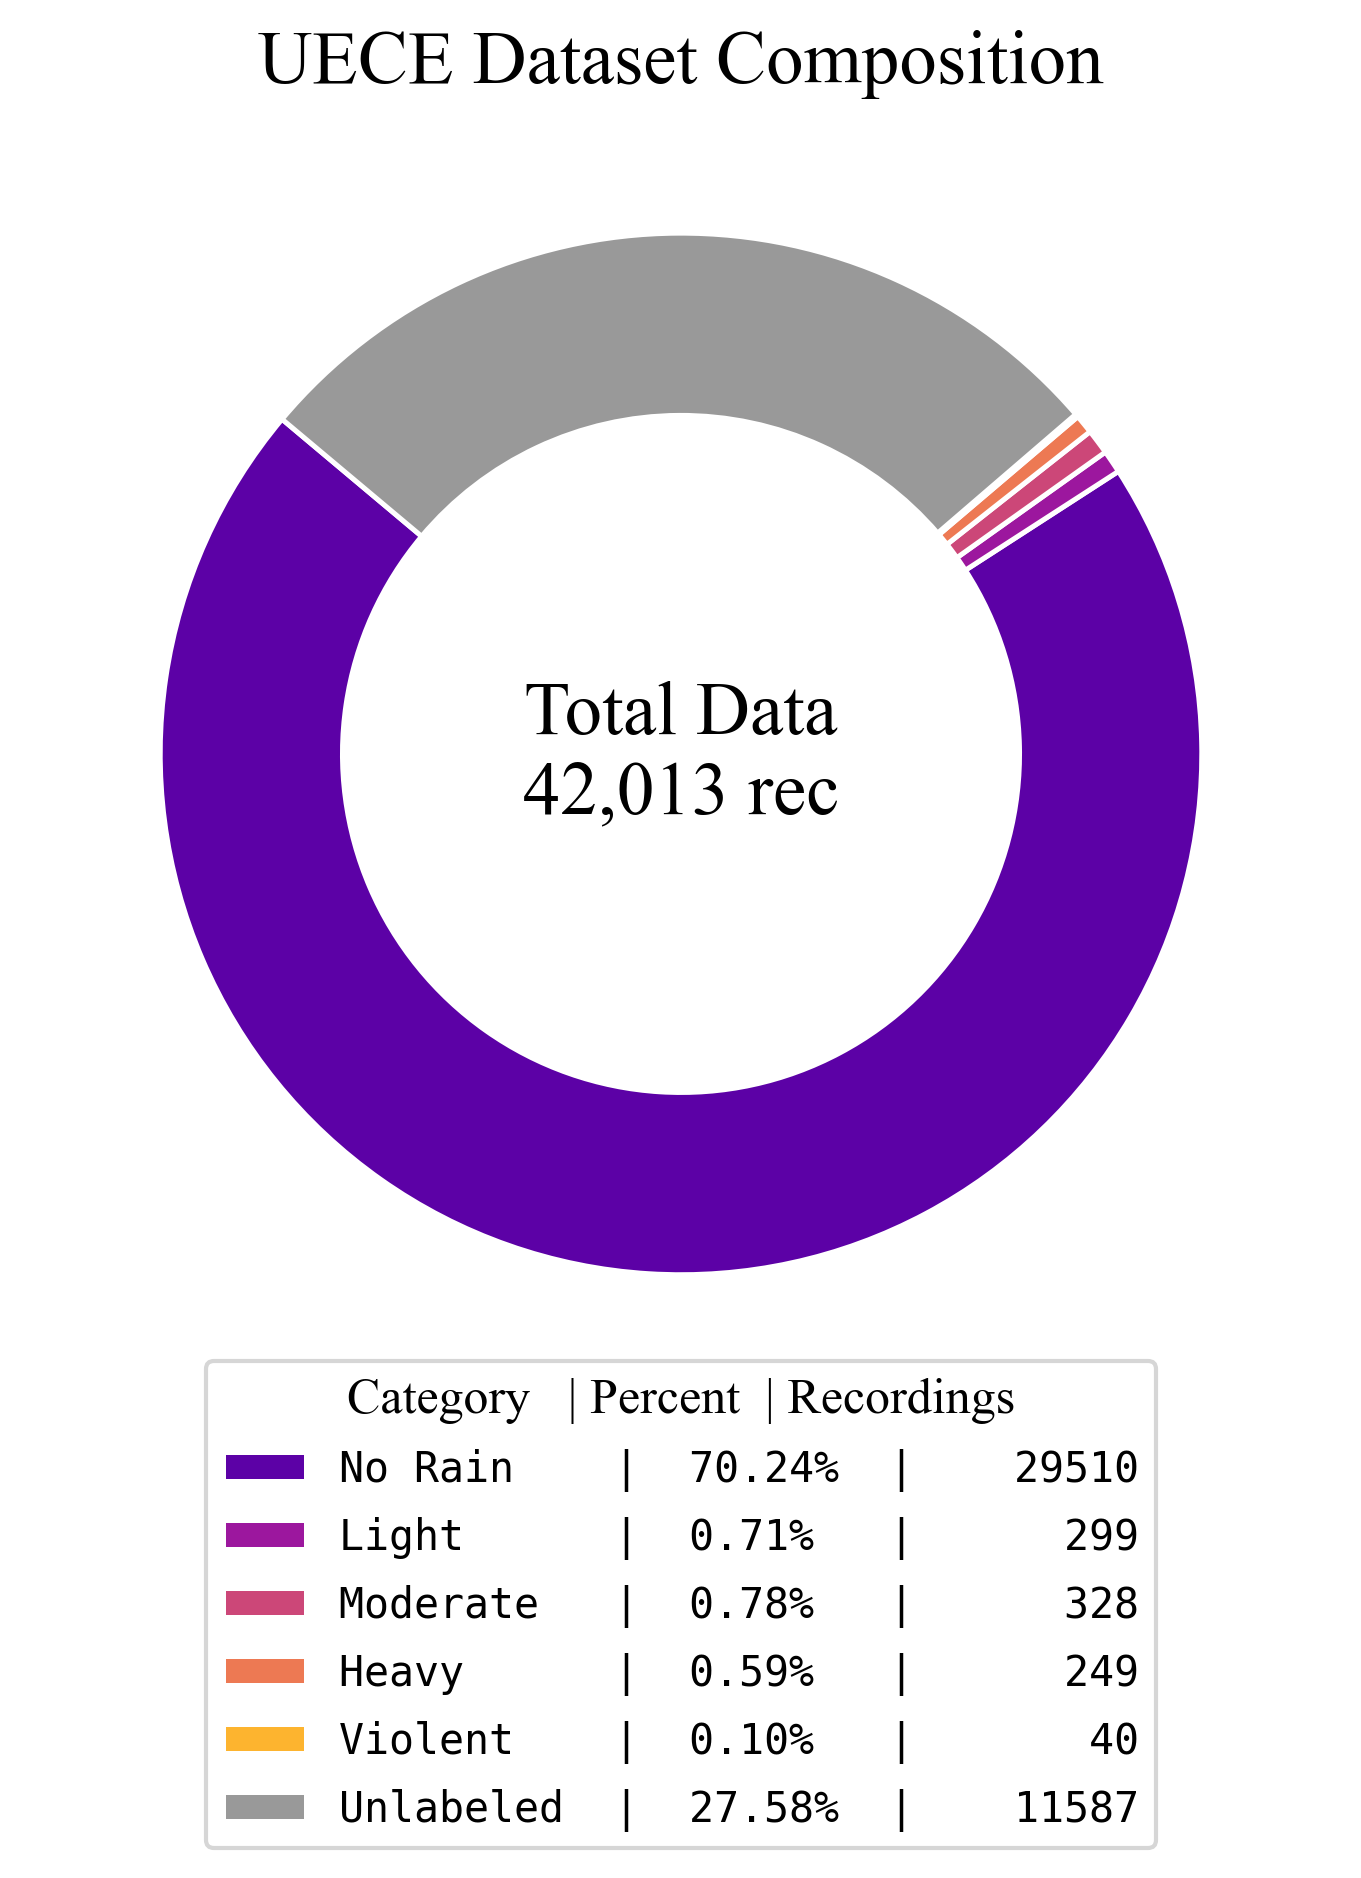

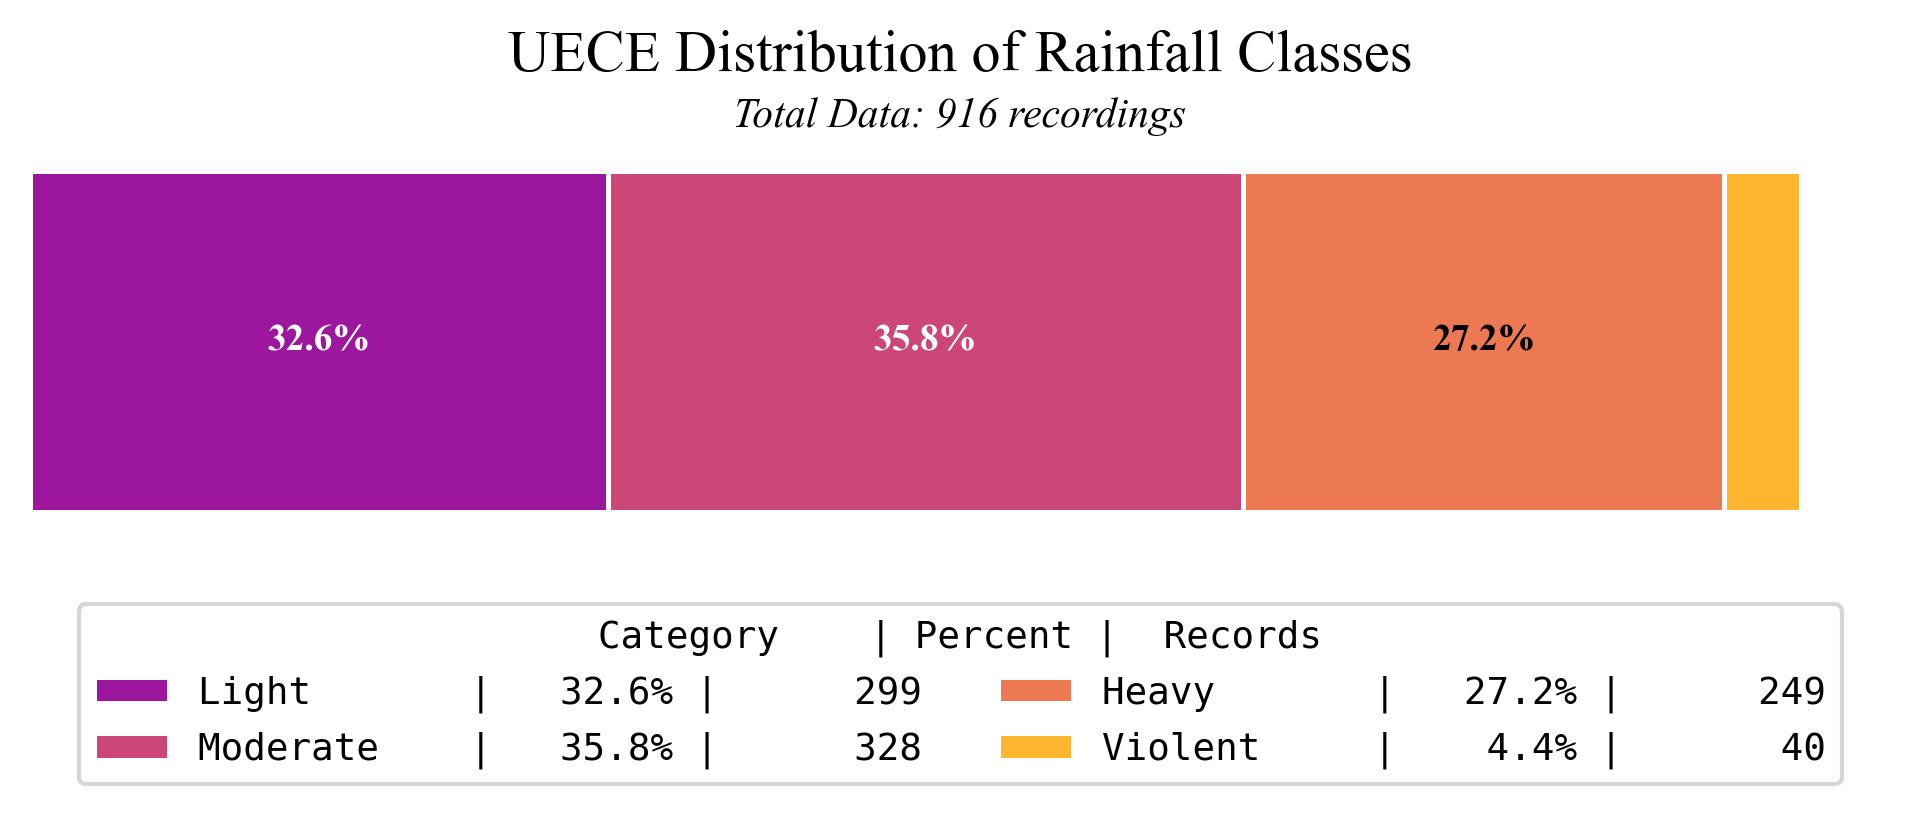

In [7]:
fig_donut_all = plot_styled_donut(df_raw_viz, engine, ALL_CLASSES, "UECE Dataset Composition")
engine.save_figure(fig_donut_all, "UECE_donut_all")

fig_bar_rain = plot_styled_stacked_bar(df_raw_viz, engine, RAIN_CLASSES, "UECE Distribution of Rainfall Classes")
engine.save_figure(fig_bar_rain, "UECE_stacked_rain")

## Monthly Distribuiton

16:06:21 - [VizEngine] - INFO - Figure saved: UECE_monthly_distribution_bars.pdf
16:06:21 - [VizEngine] - INFO - Figure saved: UECE_monthly_distribution_bars.png


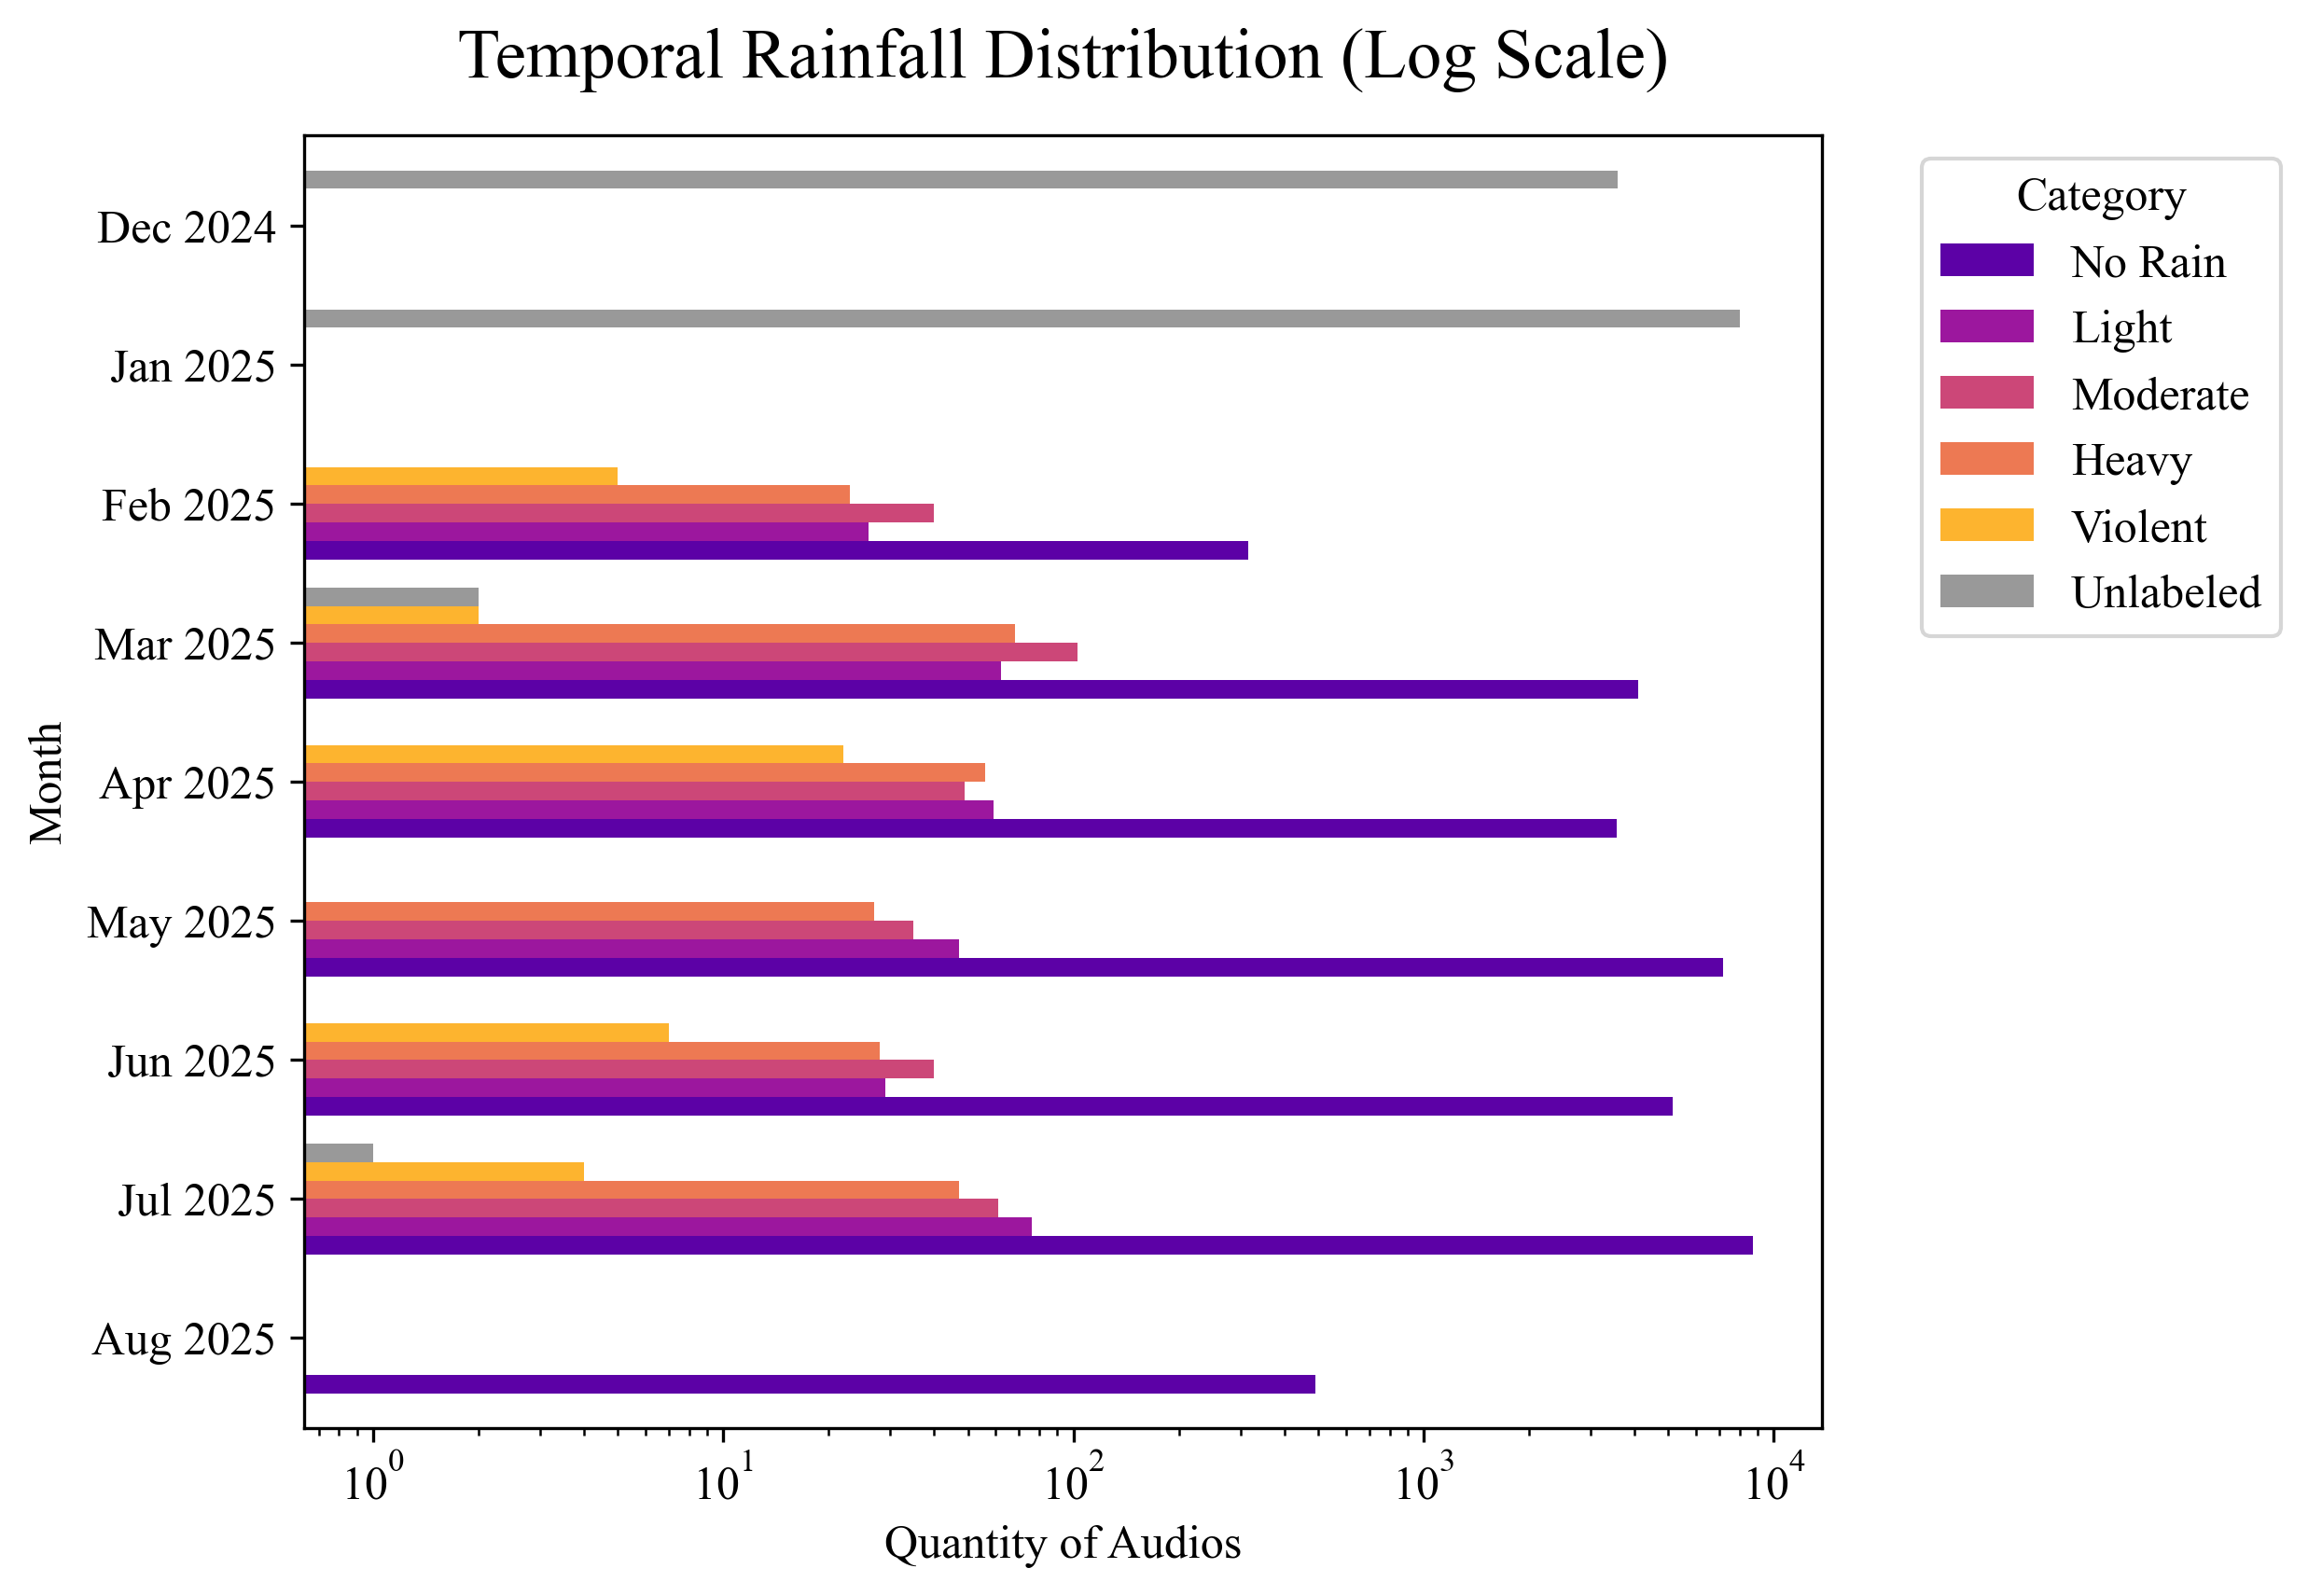

In [8]:
fig_temporal = plot_temporal_log_distribution(df_raw_viz, engine)
engine.save_figure(fig_temporal, "UECE_monthly_distribution_bars")

## Monthly Percentages

16:06:21 - [VizEngine] - INFO - Figure saved: UECE_matrix_percentages_all.pdf
16:06:21 - [VizEngine] - INFO - Figure saved: UECE_matrix_percentages_all.png
16:06:21 - [VizEngine] - INFO - Figure saved: UECE_matrix_percentages_rain.pdf
16:06:21 - [VizEngine] - INFO - Figure saved: UECE_matrix_percentages_rain.png


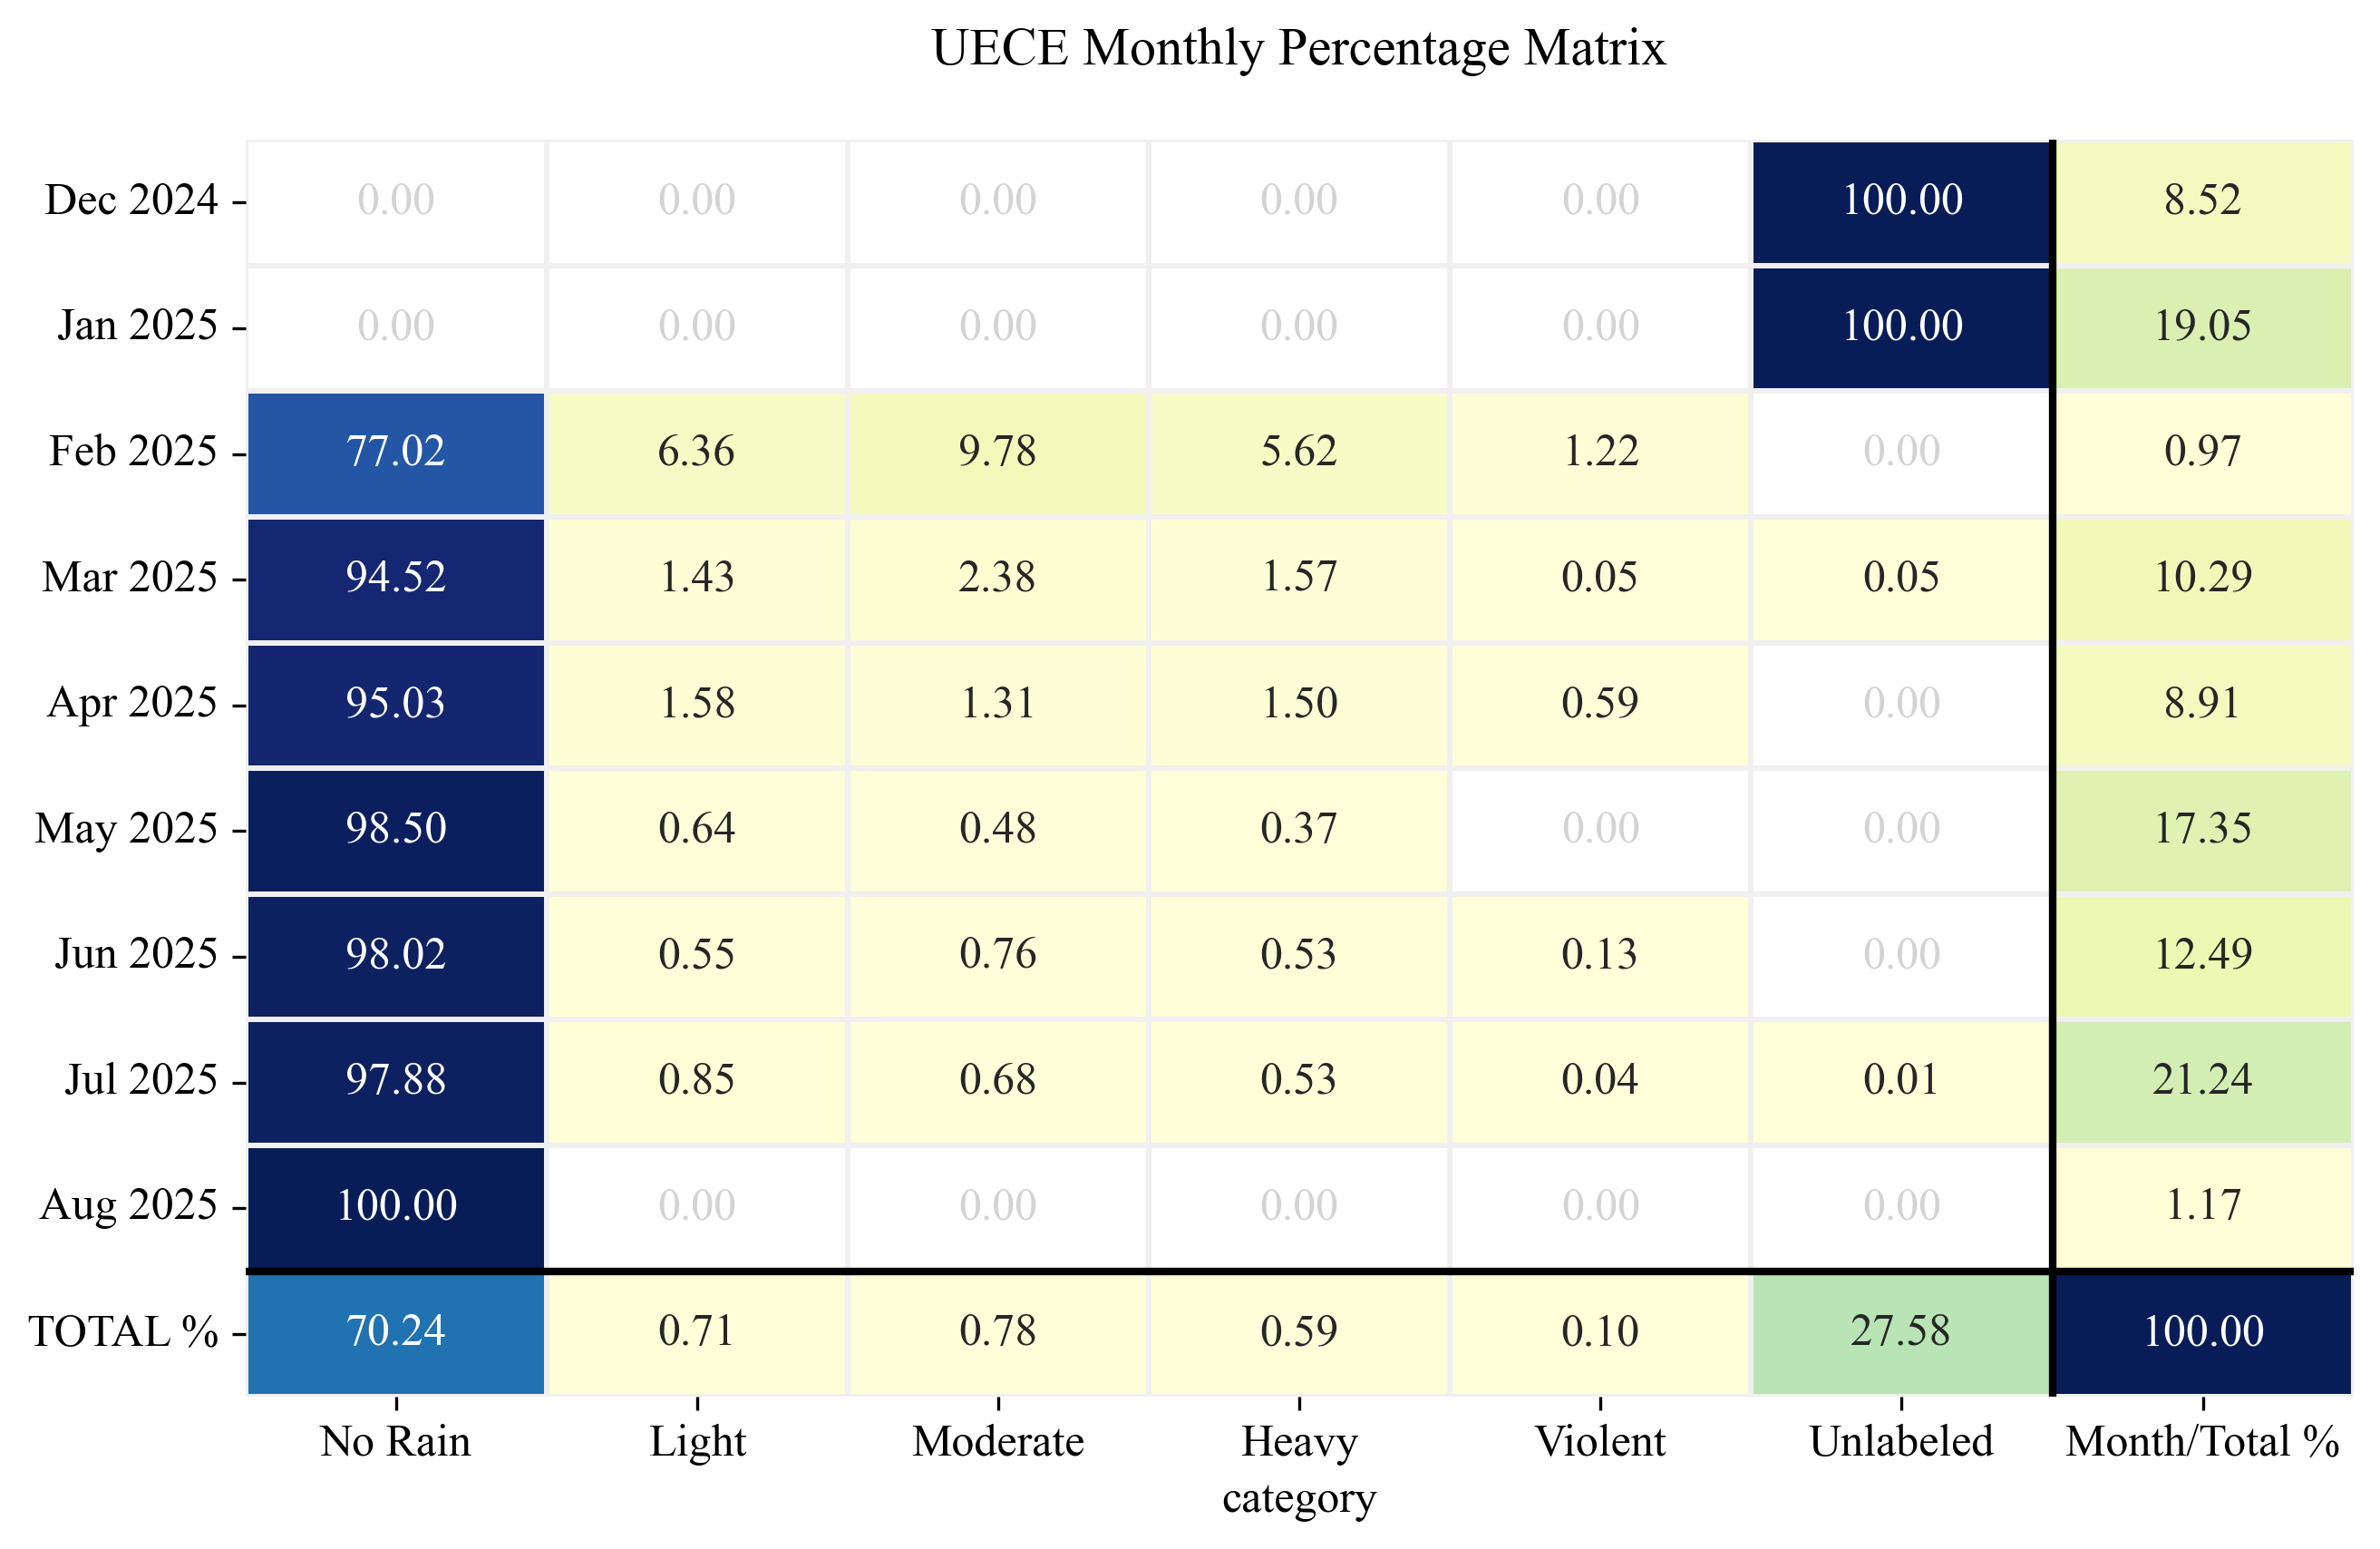

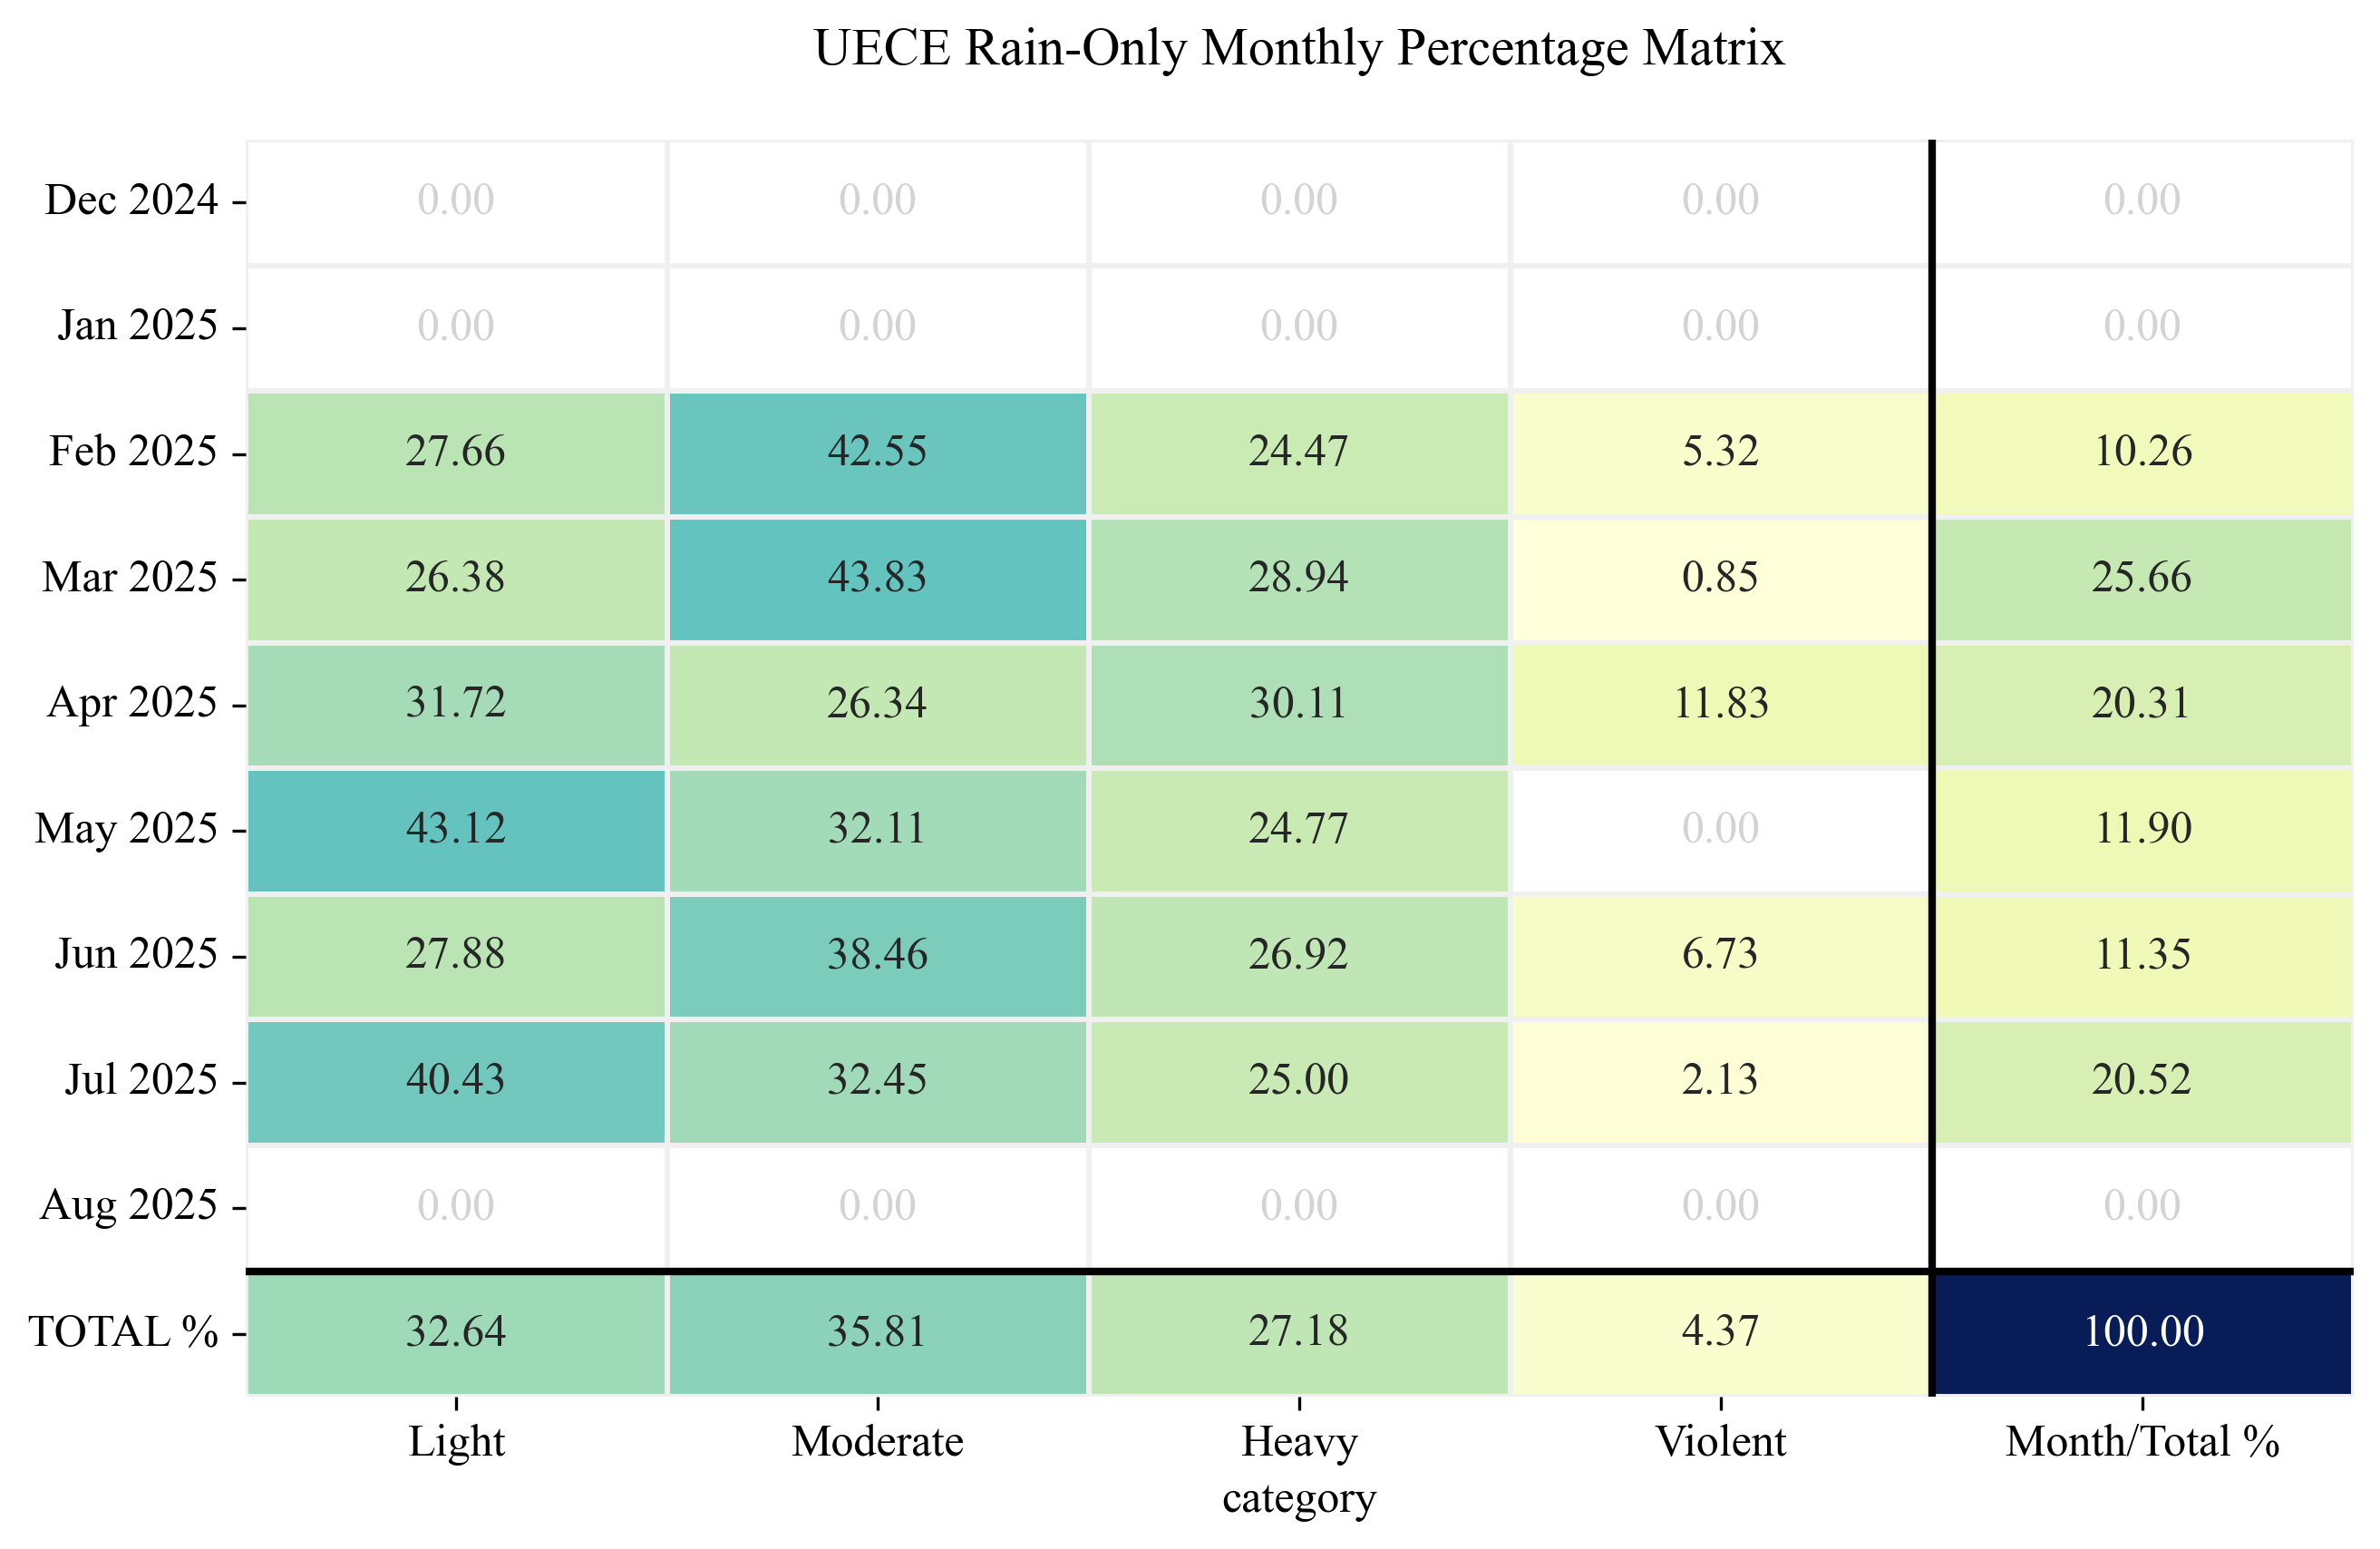

In [9]:
# All dataset
months_order = df_raw_viz['month_label'].cat.categories

matrix_p = pd.crosstab(df_raw_viz['month_label'], df_raw_viz['category'], normalize='index', dropna=False) * 100
month_weights = (df_raw_viz['month_label'].value_counts(normalize=True).reindex(months_order) * 100)
matrix_p['Month/Total %'] = month_weights

total_class_p = (df_raw_viz['category'].value_counts(normalize=True).reindex(ALL_CLASSES) * 100).to_frame().T
total_class_p.index = ['TOTAL %']
total_class_p['Month/Total %'] = 100.0
matrix_p_final = pd.concat([matrix_p, total_class_p])

fig_matrix_p = plot_custom_matrix(matrix_p_final, "UECE Monthly Percentage Matrix", fmt=".2f")
engine.save_figure(fig_matrix_p, "UECE_matrix_percentages_all")


# Only Rain data
df_rain = df_raw_viz[df_raw_viz['category'].isin(RAIN_CLASSES)].copy()
df_rain['category'] = df_rain['category'].cat.remove_unused_categories()

matrix_p_rain = pd.crosstab(df_rain['month_label'], df_rain['category'], normalize='index', dropna=False) * 100
month_weights_rain = (df_rain['month_label'].value_counts(normalize=True).reindex(months_order) * 100)
matrix_p_rain['Month/Total %'] = month_weights_rain

total_rain_p = (df_rain['category'].value_counts(normalize=True).reindex(RAIN_CLASSES) * 100).to_frame().T
total_rain_p.index = ['TOTAL %']
total_rain_p['Month/Total %'] = 100.0
matrix_p_rain_final = pd.concat([matrix_p_rain, total_rain_p])

fig_matrix_p_rain = plot_custom_matrix(matrix_p_rain_final, "UECE Rain-Only Monthly Percentage Matrix", fmt=".2f")
engine.save_figure(fig_matrix_p_rain, "UECE_matrix_percentages_rain")

## Selection

In [10]:
curated_file_path = PROJECT_ROOT / "data" / "raw" / "UECE" / "UECE_curated.csv"
one_to_one_file_path = PROJECT_ROOT / "data" / "raw" / "UECE" / "UECE_1_to_1.csv"

df_cleaned = (
    df_raw
    .pipe(discard_files, discard_rules=[
        "category == 'unlabeled'",
        "category.isnull() or mm_5min.isnull() or mm_hr.isnull()",
        "wet == True and mm_5min == 0", 
        "wet == False and mm_5min > 0" 
    ])
    .pipe(save_checkpoint, file_path=curated_file_path, index=False)
    .pipe(undersample_1_to_1, target_col='category', anchor_classes=WMO_CLASSES[1:5], sample_classes=[WMO_CLASSES[0]])
    .pipe(save_checkpoint, file_path=one_to_one_file_path, index=False)
)

16:06:22 - [DataCurator] - INFO - Applying 4 discard rule(s)...
16:06:22 - [DataCurator] - INFO - Curation complete. Remaining records: 29997 (Original: 42013).
16:06:22 - [DataBalancer] - INFO - Initiating 1:1 undersamplig on column 'category'.
16:06:22 - [DataBalancer] - INFO - Anchor group size: 894 | Pool group size: 29103
16:06:22 - [DataBalancer] - INFO - Balanced Dataset generated: 1788 total records.


In [11]:
df_curated = pd.read_csv(curated_file_path)
df_one_to_one = pd.read_csv(one_to_one_file_path)

count_raw = df_raw['category'].value_counts()
print('df_raw:')
print(count_raw, '\n')

count_curated = df_curated['category'].value_counts()
print('df_curated:')
print(count_curated, '\n')

count_one_to_one = df_one_to_one['category'].value_counts()
print('df_1_to_1:')
print(count_one_to_one, '\n')

df_raw:
category
no-rain      29510
unlabeled    11587
moderate       328
light          299
heavy          249
violent         40
Name: count, dtype: int64 

df_curated:
category
no-rain     29103
moderate      315
light         299
heavy         240
violent        40
Name: count, dtype: int64 

df_1_to_1:
category
no-rain     894
moderate    315
light       299
heavy       240
violent      40
Name: count, dtype: int64 



## Stratified Split

In [12]:
split_file_path = PROJECT_ROOT / "data" / "splits" / "UECE"

train_file_path = split_file_path / "UECE_train.csv"
val_file_path = split_file_path / "UECE_val.csv"
test_file_path = split_file_path / "UECE_test.csv"


df_train, df_val, df_test = split_dataset(
    df_cleaned, 
    test_size=0.1, 
    val_size=0.1, 
    stratify_cols=['category']
)


df_train.to_csv(train_file_path, index=False)
df_val.to_csv(val_file_path, index=False)
df_test.to_csv(test_file_path, index=False)

In [13]:
count_train = df_train['category'].value_counts()
print('TRAIN:')
print(count_train)
print("Total Samples    ", len(df_train['category']), '\n')

count_val = df_val['category'].value_counts()
print('VALIDATION:')
print(count_val)
print("Total Samples    ", len(df_val['category']), '\n')

count_test = df_test['category'].value_counts()
print('TEST')
print(count_test)
print("Total Samples    ", len(df_test['category']), '\n')

total = len(df_test['category']) + len(df_val['category']) + len(df_train['category'])

print("PERCENTAGES:")
print("Train         ", round((len(df_train['category'])/total), 2))
print("Validation    ", round((len(df_val['category'])/total), 2))
print("Test          ", round((len(df_test['category'])/total), 2))



TRAIN:
category
no-rain     715
moderate    252
light       239
heavy       192
violent      32
Name: count, dtype: int64
Total Samples     1430 

VALIDATION:
category
no-rain     90
moderate    31
light       30
heavy       24
violent      4
Name: count, dtype: int64
Total Samples     179 

TEST
category
no-rain     89
moderate    32
light       30
heavy       24
violent      4
Name: count, dtype: int64
Total Samples     179 

PERCENTAGES:
Train          0.8
Validation     0.1
Test           0.1
